# Basic DESI 

Here we are exploring more basic aspects of DESI data release , such as 
* where the DESI pointings are
* What is the format of DESI spectra


In [1]:
import astropy.table as atpy
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits

data_prefix = 'data/'

In [2]:
tiles_T = atpy.Table().read('https://data.desi.lbl.gov/public/dr1/spectro/redux/iron/tiles-iron.csv')

In [3]:
tiles_T

TILEID,SURVEY,PROGRAM,FAPRGRM,FAFLAVOR,NEXP,EXPTIME,TILERA,TILEDEC,EFFTIME_ETC,EFFTIME_SPEC,EFFTIME_GFA,GOALTIME,OBSSTATUS,LRG_EFFTIME_DARK,ELG_EFFTIME_DARK,BGS_EFFTIME_BRIGHT,LYA_EFFTIME_DARK,GOALTYPE,MINTFRAC,LASTNIGHT
int64,str7,str6,str16,str19,int64,float64,float64,float64,float64,float64,float64,float64,str8,float64,float64,float64,float64,str6,float64,int64
80615,cmx,other,m33,cmxm33,4,3600.1,24.027,31.39,0.0,3298.4,0.0,1000.0,obsend,3204.8,3298.4,3196.1,3552.9,other,0.9,20201216
80609,sv1,dark,lrgqso,cmxlrgqso,15,13500.7,150.12,2.206,0.0,7779.9,0.0,4000.0,obsend,7670.3,7779.9,7978.7,10690.3,dark,0.9,20201217
80606,sv1,dark,elg,cmxelg,12,10800.7,36.448,-4.501,0.0,6650.8,0.0,4000.0,obsend,6405.5,6650.8,6510.6,7235.5,dark,0.9,20201219
80607,sv1,dark,lrgqso,cmxlrgqso,15,13500.8,106.74,56.1,0.0,9267.0,0.0,4000.0,obsend,8556.3,9267.0,8408.0,8092.5,dark,0.9,20201219
80620,sv1,dark,lrgqso,sv1lrgqso,9,8100.5,144.0,65.0,0.0,7000.7,0.0,4000.0,obsend,6416.3,7000.7,6147.4,5818.1,dark,0.9,20201221
80622,sv1,dark,lrgqso,sv1lrgqso,6,5400.3,155.0,32.325,0.0,4901.1,0.0,4000.0,obsend,4676.9,4901.1,4702.0,6883.0,dark,0.9,20201221
80623,sv1,dark,elg,sv1elg,8,7200.4,155.0,32.425,0.0,4954.6,0.0,4000.0,obsend,4803.1,4954.6,4874.1,7151.4,dark,0.9,20201221
80611,sv1,bright,bgsmws,sv1bgsmws,12,3600.9,35.22,30.3,0.0,654.6,0.0,600.0,obsend,619.1,708.8,654.6,381.2,bright,0.9,20201222
80608,sv1,dark,elg,cmxelg,23,20701.4,106.74,56.2,0.0,14975.2,0.0,4000.0,obsend,13834.0,14975.2,13544.9,13539.6,dark,0.9,20201223


# Location of DESI main/bright tile centers

(377.25525, -17.474249999999998)

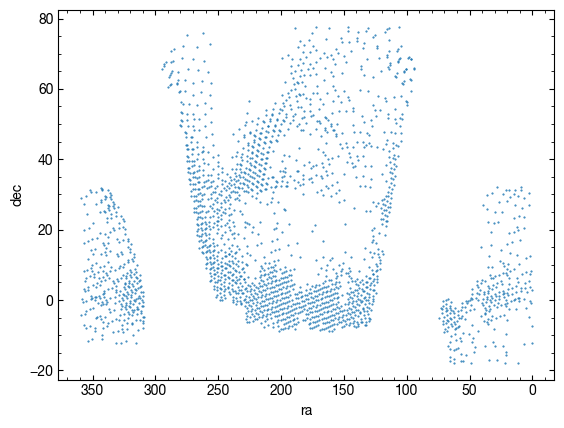

In [4]:
xind = (tiles_T['SURVEY']=='main') & (tiles_T['PROGRAM']=='bright')
plt.plot(tiles_T['TILERA'][xind],tiles_T['TILEDEC'][xind],'.',markersize=1)       
plt.xlabel('ra')
plt.ylabel('dec')
plt.xlim(*plt.xlim()[::-1])

# main/backup tile centers

The footprints are very different between different survey/programs

(336.4662, -16.0222)

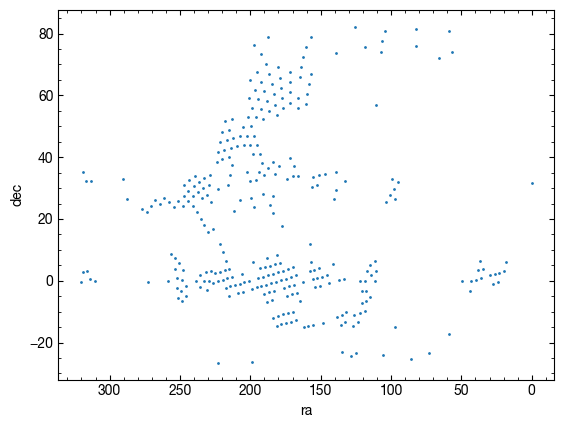

In [5]:
xind = (tiles_T['SURVEY']=='main') & (tiles_T['PROGRAM']=='backup')
plt.plot(tiles_T['TILERA'][xind],tiles_T['TILEDEC'][xind],'.',markersize=2)       
plt.xlabel('ra')
plt.ylabel('dec')
plt.xlim(*plt.xlim()[::-1])

# Effective exposure times for different tiles

DESI survey measures the depth of different exposures/tiles through effective exposure time (see https://ui.adsabs.harvard.edu/abs/2023AJ....166..259S/abstract ).

Text(0.5, 0, 'Effective exposure time for main/bright tiles')

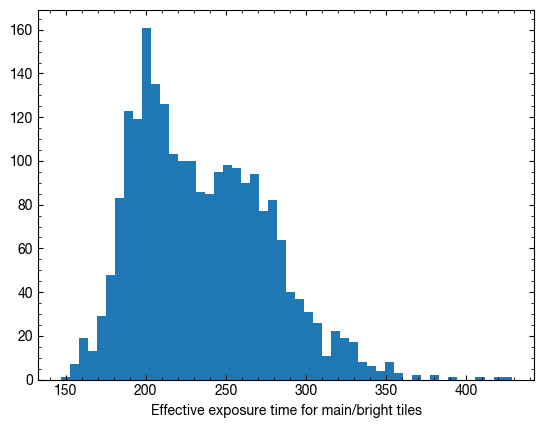

In [6]:
plt.hist(tiles_T[(tiles_T['SURVEY']=='main')&(tiles_T['PROGRAM']=='bright')]['EFFTIME_SPEC'],bins=50);
plt.xlabel('Effective exposure time for main/bright tiles')

# Structure of spectra 

In [7]:
ls data/

coadd-main-bright-10813.fits        rvpix-main-bright.fits
mwsall-pix-iron.fits                rvpix_exp-sv3-bright.fits
mwsall_dr1_slim.fits                rvtab_coadd-main-bright-10813.fits
rvmod_coadd-main-bright-10813.fits  sppix-main-bright.fits


In [8]:
pyfits.info(data_prefix + 'coadd-main-bright-10813.fits')

Filename: data/coadd-main-bright-10813.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      70   ()      
  1  FIBERMAP      1 BinTableHDU    193   411R x 67C   [K, J, D, D, E, E, E, K, B, 3A, D, J, I, 8A, J, J, 4A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, E, E, E, E, K, 2A, E, E, E, E, 1A, K, K, K, K, K, K, D, D, I, E, I, I, E, E, E, E, D, E, D, E, E]   
  2  EXP_FIBERMAP    1 BinTableHDU     64   411R x 26C   [K, J, D, J, J, D, J, D, I, J, K, J, J, E, E, E, D, D, K, D, D, D, D, D, D, D]   
  3  B_WAVELENGTH    1 ImageHDU        10   (2751,)   float64   
  4  B_FLUX        1 ImageHDU        11   (2751, 411)   float32   
  5  B_IVAR        1 ImageHDU        11   (2751, 411)   float32   
  6  B_MASK        1 ImageHDU        10   (2751, 411)   int32   
  7  B_RESOLUTION    1 ImageHDU        11   (2751, 11, 411)   float32   
  8  R_WAVELENGTH    1 ImageHDU        10   (2326,)   float64   
  9  R_FLUX        1 ImageHDU        

# Extensions

*  WAVELENGTH/FLUX/IVAR/MASK/RESOLUTION -- wavelength, flux, inverse variance, mask, resolution matrix for each arm
*    FIBERMAP -- table summarizing each target, targeting bits, photometry
*    EXP_FIBERMAP -- fibermap rows for multiple exposures contributing to the stack
*    SCORES -- key information about quality of spectra (S/N, effective exposure times etc)

In [9]:
fp = pyfits.open(data_prefix + 'coadd-main-bright-10813.fits')
print (fp['FIBERMAP'].columns)

ColDefs(
    name = 'TARGETID'; format = 'K'
    name = 'COADD_FIBERSTATUS'; format = 'J'
    name = 'TARGET_RA'; format = 'D'
    name = 'TARGET_DEC'; format = 'D'
    name = 'PMRA'; format = 'E'
    name = 'PMDEC'; format = 'E'
    name = 'REF_EPOCH'; format = 'E'
    name = 'FA_TARGET'; format = 'K'
    name = 'FA_TYPE'; format = 'B'
    name = 'OBJTYPE'; format = '3A'
    name = 'SUBPRIORITY'; format = 'D'
    name = 'OBSCONDITIONS'; format = 'J'
    name = 'RELEASE'; format = 'I'
    name = 'BRICKNAME'; format = '8A'
    name = 'BRICKID'; format = 'J'
    name = 'BRICK_OBJID'; format = 'J'
    name = 'MORPHTYPE'; format = '4A'
    name = 'EBV'; format = 'E'
    name = 'FLUX_G'; format = 'E'
    name = 'FLUX_R'; format = 'E'
    name = 'FLUX_Z'; format = 'E'
    name = 'FLUX_W1'; format = 'E'
    name = 'FLUX_W2'; format = 'E'
    name = 'FLUX_IVAR_G'; format = 'E'
    name = 'FLUX_IVAR_R'; format = 'E'
    name = 'FLUX_IVAR_Z'; format = 'E'
    name = 'FLUX_IVAR_W1'; format = 'E'


The wavelenght, flux, resolution and inverse variance are typically repeated for Blue, Red and infrared arms (with B_  R_, Z_ prefix respectively)

The resolution matrix -- is the sparse matrix that encodes the resolution of each individual pixel (see Bolton+2012, Guy+2023 for more details.

The matrix is storing only 11 numbers around the diagona, and thus the resolution matrix arrays in FITS files have sizes of 
NSPEC x 11 x NPIX where NSPEC is the number of spectra in the file, NPIX length of the spectrum in pixels.

In [10]:
print (fp['B_RESOLUTION'].data.shape)

(411, 11, 2751)


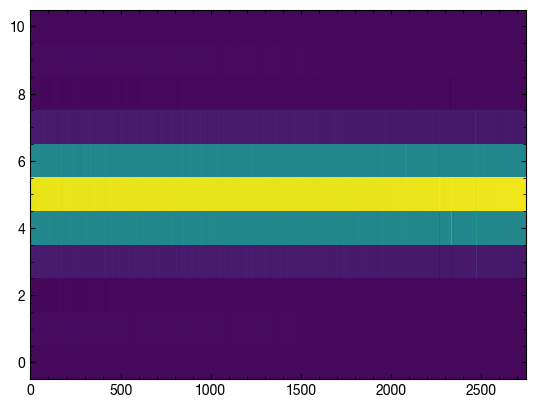

In [11]:
plt.imshow(fp['B_RESOLUTION'].data[0],origin='lower',aspect='auto',interpolation='none')

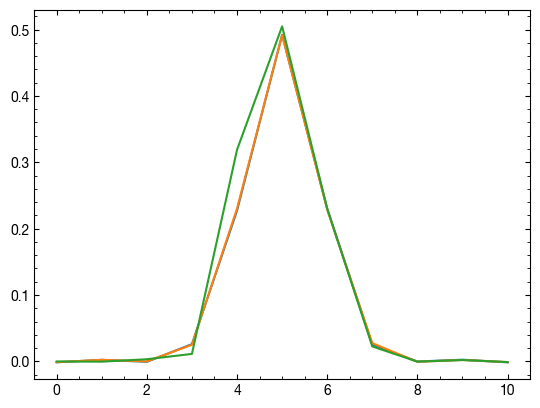

In [12]:
plt.plot(fp['B_RESOLUTION'].data[0][:,44])
plt.plot(fp['B_RESOLUTION'].data[0][:,244])
plt.plot(fp['B_RESOLUTION'].data[0][:,2337])

# Spectra, fluxes, inverse variance, masks

Text(0.5, 0, 'Wavelength [A]')

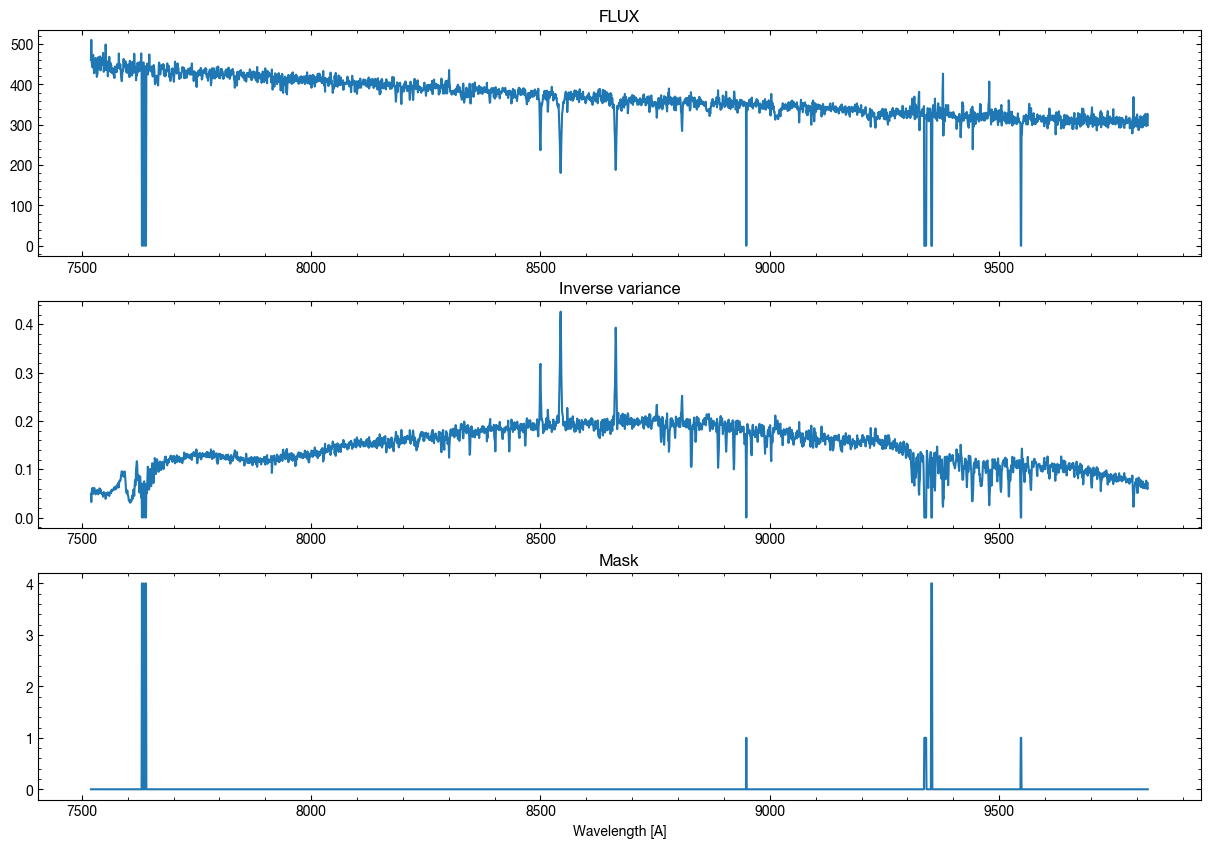

In [13]:
plt.figure(figsize=(15,10))
plt.subplot(311)
plt.plot(fp['Z_WAVELENGTH'].data,fp['Z_FLUX'].data[117])
plt.title('FLUX')
plt.subplot(312)
plt.plot(fp['Z_WAVELENGTH'].data,fp['Z_IVAR'].data[117])
plt.title('Inverse variance')
plt.subplot(313)
plt.plot(fp['Z_WAVELENGTH'].data,fp['Z_MASK'].data[117])
plt.title('Mask')
plt.xlabel('Wavelength [A]')
